# Model 1: SBI-Inspired Artifact Detector — Kaggle Version
MobileNetV3-Small trained on self-blended diverse real faces. Targets 80%+ AUC on Celeb-DF.

**Before running:** Add your Celeb-DF-v2.zip as a Kaggle dataset input (Dataset → New Dataset → upload zip). It will appear at `/kaggle/input/`.

In [1]:
import torch, os
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU — enable GPU in Settings > Accelerator'}")

BASE = '/kaggle/working/deepfake_project'
for d in [
    f'{BASE}/datasets/FairFace',
    f'{BASE}/datasets/UTKFace',
    f'{BASE}/datasets/CelebDF/real',
    f'{BASE}/datasets/CelebDF/fake',
    f'{BASE}/datasets/OpenForensics/real',
    f'{BASE}/datasets/OpenForensics/fake',
    f'{BASE}/models/model1',
    f'{BASE}/results/model1',
]:
    os.makedirs(d, exist_ok=True)

print("Directories ready.")
print(f"Kaggle input datasets available: {os.listdir('/kaggle/input/')}")

GPU: Tesla T4
Directories ready.
Kaggle input datasets available: ['datasets', 'notebooks']


## Install Dependencies

In [2]:
!pip install -q timm albumentations gdown scikit-learn tqdm pillow datasets 'mediapipe>=0.10.18' 'protobuf>=5.29.1,<6.0'
print("Done.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 77.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 83.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have

## Download FairFace
Racially balanced across 7 groups. Downloads directly via gdown.

In [3]:
import gdown, zipfile, os

FAIRFACE_DIR = f'{BASE}/datasets/FairFace'

if not os.path.exists(f'{FAIRFACE_DIR}/train'):
    print("Downloading FairFace train images (~3GB)...")
    gdown.download(
        'https://drive.google.com/uc?id=1Z1RqRo0_JiavaZw2yzZG6WETdZQ8qX86',
        f'{FAIRFACE_DIR}/fairface_train.zip', quiet=False
    )
    with zipfile.ZipFile(f'{FAIRFACE_DIR}/fairface_train.zip', 'r') as z:
        z.extractall(FAIRFACE_DIR)
    os.remove(f'{FAIRFACE_DIR}/fairface_train.zip')
    print("Extracted.")
else:
    print("FairFace already present.")

for fid, fname in [
    ('1i1L3Yqwaio7YSOCj7ftgk8ZZchPG7dmH', 'fairface_label_train.csv'),
    ('1wOdja-ezstMEp81tX1a-EYkFebev4h7D', 'fairface_label_val.csv'),
]:
    dest = f'{FAIRFACE_DIR}/{fname}'
    if not os.path.exists(dest):
        gdown.download(f'https://drive.google.com/uc?id={fid}', dest, quiet=False)

from pathlib import Path
n = len(list(Path(f'{FAIRFACE_DIR}/train').rglob('*.jpg')))
print(f"FairFace ready: {n:,} images.")

Downloading...
From (original): https://drive.google.com/uc?id=1Z1RqRo0_JiavaZw2yzZG6WETdZQ8qX86
From (redirected): https://drive.google.com/uc?id=1Z1RqRo0_JiavaZw2yzZG6WETdZQ8qX86&confirm=t&uuid=7b5cdf4a-01e0-4dd1-97d3-c3a2075b5516
To: /kaggle/working/deepfake_project/datasets/FairFace/fairface_train.zip
100%|██████████| 578M/578M [00:06<00:00, 85.2MB/s]


Extracted.


Downloading...
From: https://drive.google.com/uc?id=1i1L3Yqwaio7YSOCj7ftgk8ZZchPG7dmH
To: /kaggle/working/deepfake_project/datasets/FairFace/fairface_label_train.csv
100%|██████████| 3.79M/3.79M [00:00<00:00, 27.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wOdja-ezstMEp81tX1a-EYkFebev4h7D
To: /kaggle/working/deepfake_project/datasets/FairFace/fairface_label_val.csv
100%|██████████| 448k/448k [00:00<00:00, 19.1MB/s]


FairFace ready: 86,744 images.


## Download UTKFace
Downloaded via HuggingFace.

In [4]:
from datasets import load_dataset
from pathlib import Path
import os

UTK_DIR = f'{BASE}/datasets/UTKFace'
os.makedirs(UTK_DIR, exist_ok=True)

existing = len(list(Path(UTK_DIR).rglob('*.jpg')))
if existing > 0:
    print(f"UTKFace already present ({existing:,} images). Skipping.")
else:
    print("Downloading UTKFace from HuggingFace...")
    ds = load_dataset("py97/UTKFace-Cropped", split="train")
    saved = 0
    for i, item in enumerate(ds):
        img = item['jpg.chip.jpg']
        if img is not None:
            img.save(f'{UTK_DIR}/{i:05d}.jpg')
            saved += 1
        if i % 2000 == 0:
            print(f"  {i}/{len(ds)} ({saved} saved)")
    print(f"UTKFace ready: {saved:,} images")

README.md:   0%|          | 0.00/795 [00:00<?, ?B/s]

UTKFace.tar.gz:   0%|          | 0.00/107M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23708 [00:00<?, ? examples/s]

  0/23708 (1 saved)
  2000/23708 (2001 saved)
  4000/23708 (4001 saved)
  6000/23708 (6000 saved)
  8000/23708 (8000 saved)
  10000/23708 (10000 saved)
  12000/23708 (12000 saved)
  14000/23708 (14000 saved)
  16000/23708 (16000 saved)
  18000/23708 (18000 saved)
  20000/23708 (20000 saved)
  22000/23708 (22000 saved)
UTKFace ready: 23,707 images


## Mount Celeb-DF v2
Reads from the Kaggle dataset you added as input. Unzips to working directory.

If you haven't added it yet: go to the notebook's Data tab → Add Dataset → upload your Celeb-DF-v2.zip as a private dataset.

In [5]:
from pathlib import Path

CELEBDF_REAL_DIRS = [
    '/kaggle/input/datasets/ramyakin/celeb-df-v2/Celeb-real',
    '/kaggle/input/datasets/ramyakin/celeb-df-v2/YouTube-real',
]
CELEBDF_FAKE_DIR = '/kaggle/input/datasets/ramyakin/celeb-df-v2/Celeb-synthesis'

real_vids = []
for d in CELEBDF_REAL_DIRS:
    real_vids += list(Path(d).rglob('*.mp4'))

fake_vids = list(Path(CELEBDF_FAKE_DIR).rglob('*.mp4'))
print(f"Real: {len(real_vids)} | Fake: {len(fake_vids)}")

Real: 890 | Fake: 5639


## SBI Blending Pipeline
Uses a fast elliptical mask — no MediaPipe, no pre-caching, no dependencies. Masks computed on the fly in microseconds. Works because FairFace and UTKFace images are already face-cropped and centred.

In [6]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['GLOG_minloglevel'] = '3'

import cv2
cv2.setNumThreads(0)
import numpy as np
import albumentations as A
import random
import urllib.request

IMG_SIZE = 224  # was 128 — SBI boundary artifacts need resolution

source_aug = A.Compose([
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.8),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.Downscale(scale_range=(0.7, 0.9), p=0.3),  # resolution mismatch between source/target
])

def get_face_mask(h, w, blur_radius=31):
    """Fallback elliptical mask (used when no landmarks are found)."""
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.ellipse(mask, (w // 2, h // 2), (int(w * 0.40), int(h * 0.52)),
                0, 0, 360, 255, -1)
    return mask

# ---- Landmark-based hull masks (MediaPipe Tasks API) ----
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

_TASK_PATH = '/kaggle/working/face_landmarker.task'
if not os.path.exists(_TASK_PATH):
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/face_landmarker/'
        'face_landmarker/float16/1/face_landmarker.task', _TASK_PATH)

def make_face_mesh():
    opts = vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=_TASK_PATH),
        running_mode=vision.RunningMode.IMAGE,
        num_faces=1,
        min_face_detection_confidence=0.3)
    return vision.FaceLandmarker.create_from_options(opts)

def landmark_hull_mask(img_rgb, mesh):
    """Binary convex-hull mask from FaceLandmarker landmarks.
    Returns uint8 mask (0/255), or None if no face found."""
    h, w   = img_rgb.shape[:2]
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB,
                      data=np.ascontiguousarray(img_rgb))
    res    = mesh.detect(mp_img)
    if not res.face_landmarks:
        return None
    pts  = np.array([(lm.x * w, lm.y * h) for lm in res.face_landmarks[0]],
                    dtype=np.int32)
    hull = cv2.convexHull(pts)
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillConvexPoly(mask, hull, 255)
    return mask

def deform_mask(mask_u8):
    """SBI-style mask randomisation: random erode/dilate, elastic-ish jitter,
    soft edge, and a random blend ratio. Returns float32 mask in [0, r]."""
    m = mask_u8.copy()
    k = random.choice([0, 5, 9, 13, 17])
    if k:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        m = cv2.dilate(m, kernel) if random.random() < 0.5 else cv2.erode(m, kernel)
    h, w  = m.shape
    pts0  = np.float32([[0, 0], [w, 0], [0, h]])
    pts1  = pts0 + np.random.uniform(-0.03, 0.03, pts0.shape).astype(np.float32) * w
    m     = cv2.warpAffine(m, cv2.getAffineTransform(pts0, pts1), (w, h))
    blur  = random.choice([15, 23, 31, 47])
    m     = cv2.GaussianBlur(m, (blur, blur), 0).astype(np.float32) / 255.0
    r     = random.choice([0.25, 0.5, 0.75, 1.0, 1.0, 1.0])
    return m * r


def _shared_degrade(img):
    """Label-independent degradations applied to BOTH classes in __getitem__.
    Removes the JPEG/downscale shortcut (these cues were fake-only, so the model
    learned compression == fake; Celeb-DF reals carry H.264 + upscaled crops and
    matched the fake signature). source_aug is unchanged: the relative
    source/target mismatch remains the legitimate SBI signal."""
    h, w = img.shape[:2]
    if random.random() < 0.3:  # downscale-upscale
        s = random.uniform(0.5, 0.9)
        small = cv2.resize(img, (int(w * s), int(h * s)),
                           interpolation=random.choice([cv2.INTER_LINEAR, cv2.INTER_AREA]))
        img = cv2.resize(small, (w, h),
                         interpolation=random.choice([cv2.INTER_LINEAR, cv2.INTER_CUBIC]))
    if random.random() < 0.5:  # JPEG round-trip q30-90
        q = random.randint(30, 90)
        _, buf = cv2.imencode('.jpg', cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
                              [cv2.IMWRITE_JPEG_QUALITY, q])
        img = cv2.cvtColor(cv2.imdecode(buf, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    return img

print("SBI pipeline ready (landmark masks, IMG_SIZE =", IMG_SIZE, ")")

E0000 00:00:1781230802.920933      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781230802.985628      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781230803.541209      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781230803.541255      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781230803.541258      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781230803.541261      23 computation_placer.cc:177] computation placer already registered. Please check linka

SBI pipeline ready (landmark masks, IMG_SIZE = 224 )


## Dataset and Transforms

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

class SBIDataset(Dataset):
    CACHE_IMG  = '/kaggle/working/sbi_imgs_224.npy'
    CACHE_MASK = '/kaggle/working/sbi_masks_224.npy'
    CACHE_N    = '/kaggle/working/sbi_count.npy'

    def __init__(self, real_dirs, transform=None, max_images=None):
        if isinstance(real_dirs, str):
            real_dirs = [real_dirs]
        if os.path.exists(self.CACHE_IMG):
            print("Loading memory-mapped cache...")
            j = int(np.load(self.CACHE_N)) if os.path.exists(self.CACHE_N) else None
            self.images     = np.load(self.CACHE_IMG,  mmap_mode='r')[:j]
            self.face_masks = np.load(self.CACHE_MASK, mmap_mode='r')[:j]
            print(f"Loaded {len(self.images):,} from cache.")
        else:
            paths = []
            for d in real_dirs:
                if os.path.exists(d):
                    found = list(Path(d).rglob('*.jpg')) + list(Path(d).rglob('*.png'))
                    paths += found
                    print(f"  {d.split('/')[-1]}: {len(found):,} images")
            if max_images and len(paths) > max_images:
                random.shuffle(paths)
                paths = paths[:max_images]

            n = len(paths)
            print(f"Building memmap cache for {n:,} images...")
            imgs  = np.lib.format.open_memmap(self.CACHE_IMG,  mode='w+',
                        dtype=np.uint8, shape=(n, IMG_SIZE, IMG_SIZE, 3))
            masks = np.lib.format.open_memmap(self.CACHE_MASK, mode='w+',
                        dtype=np.uint8, shape=(n, IMG_SIZE, IMG_SIZE))
            mesh = make_face_mesh()
            j, n_fallback = 0, 0
            for p in tqdm(paths):
                img = cv2.imread(str(p))
                if img is None:
                    continue
                img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                mask = landmark_hull_mask(img, mesh)
                if mask is None:
                    mask = get_face_mask(IMG_SIZE, IMG_SIZE)
                    n_fallback += 1
                imgs[j], masks[j] = img, mask
                j += 1
            mesh.close()
            imgs.flush(); masks.flush()
            np.save(self.CACHE_N, np.array(j))
            print(f"Cached {j:,} ({n_fallback:,} ellipse fallbacks)")
            del imgs, masks
            self.images     = np.load(self.CACHE_IMG,  mmap_mode='r')[:j]
            self.face_masks = np.load(self.CACHE_MASK, mmap_mode='r')[:j]
        self.transform = transform

    def __len__(self):
        return len(self.images) * 2

    def __getitem__(self, idx):
        img      = np.array(self.images[idx // 2])   # materialise from memmap
        use_real = (idx % 2 == 1)
        if use_real:
            return _shared_degrade(img), torch.tensor(1.0)

        h, w   = img.shape[:2]
        mask   = deform_mask(np.array(self.face_masks[idx // 2]))
        source = source_aug(image=img.copy())['image']

        if random.random() > 0.5:
            src_pts = np.float32([[0,0],[w-1,0],[0,h-1],[w-1,h-1]])
            dst_pts = src_pts + np.random.uniform(-14, 14, src_pts.shape).astype(np.float32)
            source  = cv2.warpPerspective(source, cv2.getPerspectiveTransform(src_pts, dst_pts),
                                          (w, h), borderMode=cv2.BORDER_REPLICATE)

        mask3 = mask[..., None]
        blend = (source * mask3 + img * (1 - mask3)).astype(np.uint8)

        return _shared_degrade(blend), torch.tensor(0.0)

class OpenForensicsDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None, max_per_class=None):
        real = list(Path(real_dir).rglob('*.jpg')) + list(Path(real_dir).rglob('*.png'))
        fake = list(Path(fake_dir).rglob('*.jpg')) + list(Path(fake_dir).rglob('*.png'))
        if max_per_class:
            real, fake = real[:max_per_class], fake[:max_per_class]
        self.items     = [(p, 1) for p in real] + [(p, 0) for p in fake]
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label = self.items[idx]
        img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        return img, torch.tensor(float(label))

class WithTransform(Dataset):
    def __init__(self, subset, tf):
        self.subset = subset
        self.tf     = tf
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, i):
        img, label = self.subset[i]
        if isinstance(img, np.ndarray):
            img = self.tf(image=img)['image']
        return img, label

print("Dataset classes ready.")

Dataset classes ready.


## Model: Efficientnet_B0

In [8]:
import timm
import torch.nn as nn

class ArtifactDetector(nn.Module):
    def __init__(self, backbone='efficientnet_b0', pretrained=True):
        super().__init__()
        self.net = timm.create_model(backbone, pretrained=pretrained, num_classes=1)

    def forward(self, x):
        return self.net(x).squeeze(-1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ArtifactDetector()
model = model.to(device)
total      = sum(p.numel() for p in model.parameters())
trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device: {device}")
print(f"Total params: {total:,}")
print(f"Trainable params: {trainable:,}")



model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Device: cuda
Total params: 4,008,829
Trainable params: 4,008,829


## Training

In [9]:
import torch.optim as optim
from torch.amp import GradScaler, autocast
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
import json

REAL_DIRS = [
    f'{BASE}/datasets/FairFace/train',
    f'{BASE}/datasets/UTKFace',
]
MODEL_DIR   = f'{BASE}/models/model1'
RESULTS_DIR = f'{BASE}/results/model1'

RUN_TAG = 'sam_shared_degrade_v1'   # checkpoints from other configs are ignored

full_ds = SBIDataset(REAL_DIRS, transform=None, max_images=60000)
val_n   = int(0.1 * len(full_ds))
train_n = len(full_ds) - val_n
train_ds, val_ds = torch.utils.data.random_split(
    full_ds, [train_n, val_n],
    generator=torch.Generator().manual_seed(42)
)

def worker_init(_):
    cv2.setNumThreads(0)

# ---- Proven memory profile: single GPU, batch 64, lean prefetch ----
# (DP + batch 128 + prefetch 4 OOM'd host RAM in a batch session on 2026-06-11)
train_model = model
print(f"GPUs visible: {torch.cuda.device_count()} | using 1 | train batch: 64")

train_loader = DataLoader(WithTransform(train_ds, train_tf),
                          batch_size=64, shuffle=True,  num_workers=4,
                          pin_memory=True, persistent_workers=True,
                          prefetch_factor=2, worker_init_fn=worker_init)
val_loader   = DataLoader(WithTransform(val_ds,   val_tf),
                          batch_size=64, shuffle=False, num_workers=4,
                          pin_memory=True, persistent_workers=False,
                          worker_init_fn=worker_init)

# ---- SAM (Foret et al., ICLR 2021) — paper-faithful for SBI ----
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super().__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups   = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group['rho'] / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None:
                    continue
                e_w = p.grad * scale.to(p)
                p.add_(e_w)                      # climb to worst nearby point
                self.state[p]['e_w'] = e_w
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None or 'e_w' not in self.state[p]:
                    continue
                p.sub_(self.state[p]['e_w'])     # back to original weights
        self.base_optimizer.step()               # descend using perturbed-point gradient
        if zero_grad:
            self.zero_grad()

    def _grad_norm(self):
        dev = self.param_groups[0]['params'][0].device
        return torch.norm(torch.stack([
            p.grad.norm(p=2).to(dev)
            for group in self.param_groups
            for p in group['params'] if p.grad is not None]), p=2)

# BN running stats must only update on the FIRST forward pass each step
def _set_bn_momentum_zero(m):
    for mod in m.modules():
        if isinstance(mod, nn.modules.batchnorm._BatchNorm):
            mod.backup_momentum = mod.momentum
            mod.momentum = 0
def _restore_bn_momentum(m):
    for mod in m.modules():
        if isinstance(mod, nn.modules.batchnorm._BatchNorm) and hasattr(mod, 'backup_momentum'):
            mod.momentum = mod.backup_momentum

optimizer = SAM(model.parameters(), optim.Adam, rho=0.05, lr=1e-4, weight_decay=1e-5)
EPOCHS    = 15
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCEWithLogitsLoss()
scaler    = GradScaler('cuda')   # unused by SAM loop; kept for the fine-tune cell

# Resume from checkpoint if one exists AND it belongs to this config
best_auc    = 0.0
history     = []
start_epoch = 0

checkpoints = list(Path(MODEL_DIR).glob('ckpt_epoch*.pth'))
if checkpoints:
    latest = max(checkpoints, key=lambda p: int(p.stem.split('epoch')[1]))
    ckpt   = torch.load(latest, map_location=device, weights_only=False)
    if ckpt.get('tag') == RUN_TAG:
        model.load_state_dict({k.replace('module.', ''): v for k, v in ckpt['state'].items()})
        optimizer.base_optimizer.load_state_dict(ckpt['opt'])
        start_epoch = ckpt['epoch']
        best_auc    = ckpt['auc']
        history     = ckpt.get('history', [])
        for _ in range(start_epoch):
            scheduler.step()                     # fast-forward LR schedule
        print(f"Resuming from epoch {start_epoch}, best AUC so far: {best_auc:.4f}")
    else:
        print(f"Found checkpoint with tag {ckpt.get('tag')!r} != {RUN_TAG!r} — IGNORING (starting fresh).")
else:
    print("Starting fresh.")

print(f"Train: {train_n} | Val: {val_n}")

for epoch in range(start_epoch, EPOCHS):
    train_model.train()
    train_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [train]'):
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # SAM pass 1: gradient at current weights -> climb
        loss = criterion(train_model(imgs), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.first_step(zero_grad=True)

        # SAM pass 2: gradient at perturbed weights -> descend (BN stats frozen)
        _set_bn_momentum_zero(model)
        criterion(train_model(imgs), labels).backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.second_step(zero_grad=True)
        _restore_bn_momentum(model)

        train_loss += loss.item()

    train_model.eval()
    preds_all, labels_all, val_loss = [], [], 0.0
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [val]'):
            imgs, labels = imgs.to(device), labels.to(device)
            with autocast('cuda'):
                out  = train_model(imgs)
                loss = criterion(out, labels)
            val_loss   += loss.item()
            preds_all.extend(torch.sigmoid(out.float()).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    auc = roc_auc_score(labels_all, preds_all)
    scheduler.step()

    log = dict(epoch=epoch+1,
               train_loss=round(train_loss/len(train_loader), 4),
               val_loss=round(val_loss/len(val_loader), 4),
               val_auc=round(auc, 4))
    history.append(log)
    print(f"  train_loss={log['train_loss']} | val_loss={log['val_loss']} | AUC={auc:.4f}")

    state = model.state_dict()
    torch.save({'epoch': epoch+1, 'state': state,
                'opt': optimizer.base_optimizer.state_dict(),
                'auc': auc, 'tag': RUN_TAG, 'history': history},
               f'{MODEL_DIR}/ckpt_epoch{epoch+1}.pth')

    if auc > best_auc:
        best_auc = auc
        torch.save(state, f'{MODEL_DIR}/best.pth')
        print(f"  >>> New best: {best_auc:.4f} saved.")

    if auc < 0.70 and epoch == 2:
        print("WARNING: AUC below 0.70 at epoch 3. Check dataset quality.")

with open(f'{RESULTS_DIR}/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)
print(f"\nTraining done. Best val AUC: {best_auc:.4f}")


  train: 86,744 images
  UTKFace: 23,707 images
Building memmap cache for 60,000 images...


W0000 00:00:1781230830.846976     100 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781230830.891821     103 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781230830.916975     105 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
100%|██████████| 60000/60000 [20:08<00:00, 49.64it/s]


Cached 60,000 (6,636 ellipse fallbacks)
GPUs visible: 2 | using 1 | train batch: 64
Starting fresh.
Train: 108000 | Val: 12000


Epoch 1/15 [val]: 100%|██████████| 188/188 [00:34<00:00,  5.40it/s]
/tmp/ipykernel_23/3614708182.py:159: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


  train_loss=0.4912 | val_loss=0.2836 | AUC=0.9452
  >>> New best: 0.9452 saved.


...

  train_loss=0.176 | val_loss=0.1717 | AUC=0.9749


Epoch 14/15 [val]: 100%|██████████| 188/188 [00:27<00:00,  6.95it/s]


  train_loss=0.1702 | val_loss=0.1714 | AUC=0.9736


Epoch 15/15 [val]: 100%|██████████| 188/188 [00:27<00:00,  6.96it/s]


  train_loss=0.1703 | val_loss=0.1675 | AUC=0.9758

Training done. Best val AUC: 0.9759


## Fine-tune on OpenForensics
Skipped automatically if OpenForensics is not available.

In [10]:
# Auto-discover OpenForensics: checks /kaggle/input first, then BASE
OF_REAL, OF_FAKE = None, None
candidates = [Path('/kaggle/input'), Path(f'{BASE}/datasets')]
for root in candidates:
    if not root.exists():
        continue
    hits = [p for p in root.rglob('real') if p.is_dir() and 'openforensics' in str(p).lower()]
    for r in hits:
        f = r.parent / 'fake'
        if f.is_dir():
            OF_REAL, OF_FAKE = str(r), str(f)
            break
    if OF_REAL:
        break
print(f"OpenForensics: real={OF_REAL} fake={OF_FAKE}")

if OF_REAL and os.listdir(OF_REAL) and os.listdir(OF_FAKE):
    model.load_state_dict(torch.load(f'{MODEL_DIR}/best.pth', map_location=device))
    of_ds  = OpenForensicsDataset(OF_REAL, OF_FAKE, max_per_class=5000)
    val_n  = int(0.1 * len(of_ds))
    of_tr, of_va = torch.utils.data.random_split(of_ds, [len(of_ds)-val_n, val_n])
    of_tr_loader = DataLoader(WithTransform(of_tr, train_tf), batch_size=32, shuffle=True,  num_workers=2)
    of_va_loader = DataLoader(WithTransform(of_va, val_tf),   batch_size=64, shuffle=False, num_workers=2)

    ft_opt = optim.Adam(model.parameters(), lr=1e-5)
    ft_sch = optim.lr_scheduler.CosineAnnealingLR(ft_opt, T_max=3)

    print(f"Fine-tuning on {len(of_ds)} OpenForensics samples...")
    for epoch in range(3):
        model.train()
        for imgs, labels in tqdm(of_tr_loader, desc=f'FT {epoch+1}/3'):
            imgs, labels = imgs.to(device), labels.to(device)
            ft_opt.zero_grad()
            with autocast('cuda'):
                loss = criterion(model(imgs), labels)
            scaler.scale(loss).backward()
            scaler.step(ft_opt)
            scaler.update()
        ft_sch.step()

        model.eval()
        p, l = [], []
        with torch.no_grad():
            for imgs, labels in of_va_loader:
                imgs = imgs.to(device)
                p.extend(torch.sigmoid(model(imgs)).cpu().numpy())
                l.extend(labels.numpy())
        auc = roc_auc_score(l, p)
        print(f"  FT epoch {epoch+1}: AUC={auc:.4f}")
        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), f'{MODEL_DIR}/best.pth')
            print(f"  >>> New best: {best_auc:.4f}")
    print("Fine-tuning complete.")
else:
    print("OpenForensics not found — attach it via Add Input (folder must contain real/ and fake/ subdirs).")

OpenForensics: real=/kaggle/working/deepfake_project/datasets/OpenForensics/real fake=/kaggle/working/deepfake_project/datasets/OpenForensics/fake
OpenForensics not found — attach it via Add Input (folder must contain real/ and fake/ subdirs).


## Evaluate on Celeb-DF
Skipped automatically if Celeb-DF videos are not available.

Real: 890 | Fake: 5639
Haar fallback: 193/6400 frames (3.0%)
Real: scored 200/200
Haar fallback: 256/12800 frames (2.0%)
Fake: scored 200/200

Celeb-DF AUC: 0.7224


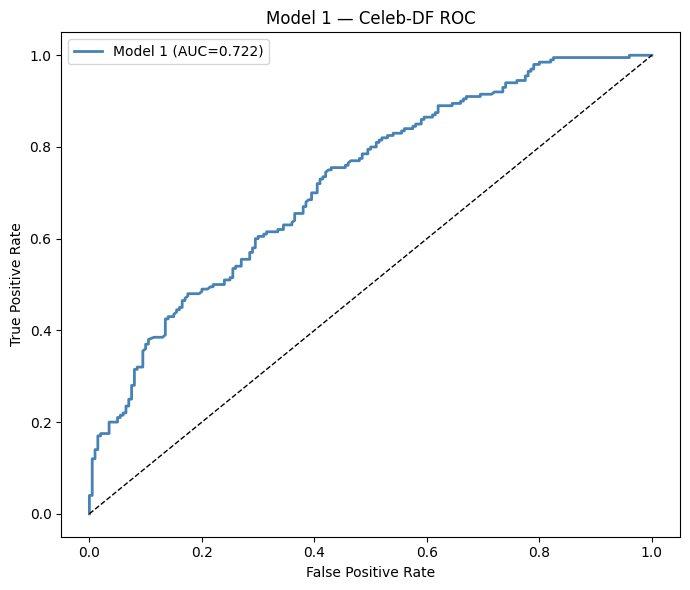

Results saved to /kaggle/working/deepfake_project/results/model1


In [11]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import threading
from concurrent.futures import ThreadPoolExecutor

# CascadeClassifier is NOT thread-safe — give each decoder thread its own copy
_tls = threading.local()
_fallback_count = [0, 0]   # [fallbacks, total]

def _get_cascade():
    if not hasattr(_tls, 'cascade'):
        _tls.cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    return _tls.cascade

def _crop_face(frame, margin=0.3):
    """Crop largest detected face with margin. Matches training distribution
    (FairFace/UTKFace are face crops). Falls back to center square crop."""
    _fallback_count[1] += 1
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = _get_cascade().detectMultiScale(gray, scaleFactor=1.1,
                                            minNeighbors=5, minSize=(60, 60))
    H, W = frame.shape[:2]
    if len(faces) > 0:
        x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
        m  = int(margin * max(w, h))
        x0, y0 = max(0, x - m), max(0, y - m)
        x1, y1 = min(W, x + w + m), min(H, y + h + m)
        return frame[y0:y1, x0:x1]
    # fallback: center square (better than full frame)
    _fallback_count[0] += 1
    side = min(H, W)
    y0, x0 = (H - side) // 2, (W - side) // 2
    return frame[y0:y0 + side, x0:x0 + side]
    
def _decode_frames(vpath, n_frames=10):
    """Decode n evenly spaced frames sequentially, face-crop each."""
    cap   = cv2.VideoCapture(str(vpath))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        return None
    want   = set(np.linspace(0, total - 1, n_frames, dtype=int).tolist())
    frames = []
    idx    = 0
    while idx <= max(want) and cap.grab():
        if idx in want:
            ret, frame = cap.retrieve()
            if ret:
                face = _crop_face(frame)
                frames.append(cv2.cvtColor(cv2.resize(face, (IMG_SIZE, IMG_SIZE)),
                                           cv2.COLOR_BGR2RGB))
        idx += 1
    cap.release()
    return frames or None

def predict_video_batch(vpaths, model, tf, device, n_frames=32, decode_workers=4):
    """Decode videos in parallel threads, score each video's frames in ONE forward pass."""
    model.eval()
    results = [None] * len(vpaths)
    with ThreadPoolExecutor(max_workers=decode_workers) as ex, torch.no_grad():
        for i, frames in enumerate(ex.map(lambda p: _decode_frames(p, n_frames), vpaths)):
            if not frames:
                continue
            batch = torch.stack([tf(image=f)['image'] for f in frames]).to(device)
            with autocast('cuda'):
                probs = torch.sigmoid(model(batch))
            results[i] = float(probs.mean().item())
    print(f"Haar fallback: {_fallback_count[0]}/{_fallback_count[1]} frames "
      f"({100*_fallback_count[0]/max(1,_fallback_count[1]):.1f}%)")
    return results

CELEBDF_REAL_DIRS = [
    '/kaggle/input/datasets/ramyakin/celeb-df-v2/Celeb-real',
    '/kaggle/input/datasets/ramyakin/celeb-df-v2/YouTube-real',
]
CELEBDF_FAKE_DIR = '/kaggle/input/datasets/ramyakin/celeb-df-v2/Celeb-synthesis'

real_vids = []
for d in CELEBDF_REAL_DIRS:
    real_vids += list(Path(d).rglob('*.mp4'))
fake_vids = list(Path(CELEBDF_FAKE_DIR).rglob('*.mp4'))
print(f"Real: {len(real_vids)} | Fake: {len(fake_vids)}")

if not real_vids or not fake_vids:
    print("Celeb-DF videos not found. Add the dataset and re-run.")
else:
    model.load_state_dict(torch.load(f'{MODEL_DIR}/best.pth',
                                     map_location=device, weights_only=False))
    scores, labels = [], []

    for vids, lab, name in [(real_vids[:200], 1, 'Real'), (fake_vids[:200], 0, 'Fake')]:
        res = predict_video_batch(vids, model, val_tf, device)
        for s_ in res:
            if s_ is not None:
                scores.append(s_); labels.append(lab)
        print(f"{name}: scored {sum(r is not None for r in res)}/{len(vids)}")

    auc = roc_auc_score(labels, scores)
    print(f"\nCeleb-DF AUC: {auc:.4f}")
    if auc < 0.75:
        print("WARNING: below 0.75 — check eval preprocessing matches training.")

    fpr, tpr, _ = roc_curve(labels, scores)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f'Model 1 (AUC={auc:.3f})', color='steelblue', lw=2)
    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Model 1 — Celeb-DF ROC')
    plt.legend(); plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/roc_celebdf.png', dpi=150)
    plt.show()

    with open(f'{RESULTS_DIR}/celebdf_eval.json', 'w') as f:
        json.dump({'auc': round(auc,4), 'n_real': labels.count(1),
                   'n_fake': labels.count(0)}, f, indent=2)
    print(f"Results saved to {RESULTS_DIR}")

In [12]:
# --- Hypothesis test: does JPEG re-compression push scores toward "fake"? ---

def _jpeg(img):
    q = random.randint(30, 90)
    _, buf = cv2.imencode('.jpg', cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
                          [cv2.IMWRITE_JPEG_QUALITY, q])
    return cv2.cvtColor(cv2.imdecode(buf, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

test_vids = real_vids[:50]

# pass 1: normal pipeline
clean = predict_video_batch(test_vids, model, val_tf, device)

# pass 2: same videos, JPEG re-encode each cropped frame
_orig_decode = _decode_frames
def _decode_frames(vpath, n_frames=32):
    frames = _orig_decode(vpath, n_frames)
    return [_jpeg(f) for f in frames] if frames else None

jpeg = predict_video_batch(test_vids, model, val_tf, device)
_decode_frames = _orig_decode   # restore the original

c = [s for s in clean if s is not None]
j = [s for s in jpeg  if s is not None]
print(f"clean mean score: {np.mean(c):.3f}  |  jpeg mean score: {np.mean(j):.3f}")

Haar fallback: 311/14400 frames (2.2%)
Haar fallback: 366/16000 frames (2.3%)
clean mean score: 0.524  |  jpeg mean score: 0.717


## Cross-Scope Check: ROSE (presentation attacks)
Model 1 is a blend-artifact detector; replay/print attacks contain a *genuine* face, so **expected result is ~0.5 AUC**. This is a complementarity check for the fusion story (mirror of Model 2 on Celeb-DF), not part of the 0.80 target. If AUC lands well above 0.5, a texture shortcut may have survived — investigate.


In [13]:
# --- Cross-scope: Model 1 on ROSE presentation attacks (guarded, skips if absent) ---
GENUINE_CODES = {'g', 'genuine', 'real', 'live'}
ATTACK_CODES  = {'ps', 'pq', 'vl', 'vm', 'mc', 'mf', 'mu', 'attack', 'fake', 'spoof'}
VID_EXTS      = ('.mp4', '.avi', '.mov', '.mkv')

def _rose_label(p):
    """1 = genuine, 0 = attack, None = can't tell.
    Checks parent folder names first, then ROSE-Youtu filename tokens."""
    parts = [s.lower() for s in p.parts[-3:-1]]          # parent dirs
    for s in parts:
        if s in GENUINE_CODES: return 1
        if s in ATTACK_CODES:  return 0
    toks = p.stem.lower().replace('-', '_').split('_')   # filename tokens
    for t in toks:
        if t in ATTACK_CODES: return 0
    if 'g' in toks:                                       # bare G token = genuine
        return 1
    return None

ROSE_ROOT = None
for root in [Path('/kaggle/input'), Path(f'{BASE}/datasets')]:
    if not root.exists():
        continue
    hits = [p for p in root.iterdir() if 'rose' in p.name.lower()]
    if hits:
        ROSE_ROOT = hits[0]
        break

if ROSE_ROOT is None:
    print("ROSE not found under /kaggle/input or BASE/datasets — skipping cross-scope check.")
else:
    vids = [p for p in ROSE_ROOT.rglob('*') if p.suffix.lower() in VID_EXTS]
    genuine = [p for p in vids if _rose_label(p) == 1]
    attacks = [p for p in vids if _rose_label(p) == 0]
    unknown = len(vids) - len(genuine) - len(attacks)
    print(f"ROSE @ {ROSE_ROOT}: {len(genuine)} genuine | {len(attacks)} attack | {unknown} unlabelled (ignored)")

    if not genuine or not attacks:
        print("Could not derive both classes from folder/filename structure — skipping. "
              "Check layout and adjust _rose_label().")
    else:
        N = 150  # sanity check, not a benchmark — keep runtime bounded
        random.seed(42)
        g_s = random.sample(genuine, min(N, len(genuine)))
        a_s = random.sample(attacks, min(N, len(attacks)))

        model.load_state_dict(torch.load(f'{MODEL_DIR}/best.pth', map_location=device))
        g_scores = predict_video_batch(g_s, model, val_tf, device, n_frames=16)
        a_scores = predict_video_batch(a_s, model, val_tf, device, n_frames=16)
        g_scores = [s for s in g_scores if s is not None]
        a_scores = [s for s in a_scores if s is not None]

        y = [1] * len(g_scores) + [0] * len(a_scores)
        s = g_scores + a_scores
        rose_auc = roc_auc_score(y, s)
        print(f"\nROSE cross-scope AUC: {rose_auc:.4f}  (expected ~0.5 by design)")
        print(f"  genuine mean score: {np.mean(g_scores):.3f} | attack mean score: {np.mean(a_scores):.3f}")
        if rose_auc > 0.65:
            print("  NOTE: well above chance — a texture/recapture shortcut may persist. Investigate before claiming clean separation of scopes.")

        with open(f'{RESULTS_DIR}/rose_crossscope.json', 'w') as f:
            json.dump({'auc': round(rose_auc, 4),
                       'n_genuine': len(g_scores), 'n_attack': len(a_scores),
                       'genuine_mean': round(float(np.mean(g_scores)), 4),
                       'attack_mean':  round(float(np.mean(a_scores)), 4),
                       'framing': 'cross-scope complementarity check; ~0.5 expected; NOT part of Celeb-DF target'},
                      f, indent=2)
        print(f"Saved -> {RESULTS_DIR}/rose_crossscope.json")


ROSE not found under /kaggle/input or BASE/datasets — skipping cross-scope check.
